# T04 — Target and Feature Relationship EDA

**Objective:** describe the distribution of `RainTomorrow` and its relationships with the original predictors before any preprocessing or feature-engineering decisions.

**Boundary:** this notebook does not impute values, remove rows or outliers, encode categories, create model features, split data, or train a model. Pairwise summaries use available values and report sample sizes. Any month/year/season columns exist only inside temporary EDA summaries; Southern Hemisphere season is **not** an approved engineered feature. T05 is not started here.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from fdm_rainfall.data import load_weather_data
from fdm_rainfall.relationships import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    categorical_target_summary,
    correlation_analysis,
    location_target_rates,
    numeric_target_summary,
    raintoday_rainfall_relationship,
    relationship_interpretations,
    target_association_summary,
    target_distribution,
    temporal_target_rates,
)

DATASET_PATH = PROJECT_ROOT / "data/raw/weatherAUS.csv"
TABLE_DIR = PROJECT_ROOT / "reports/tables"
TARGET_FIGURE_DIR = PROJECT_ROOT / "reports/figures/target_analysis"
RELATIONSHIP_FIGURE_DIR = PROJECT_ROOT / "reports/figures/relationships"
for directory in (TABLE_DIR, TARGET_FIGURE_DIR, RELATIONSHIP_FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
NO_COLOR, YES_COLOR, NEUTRAL_COLOR = "#4C78A8", "#E45756", "#777777"
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 120)

## Load the unchanged raw dataset

The loader reads the CSV without cleaning or mutation. All target comparisons below use labelled rows where a target label is required; missing targets remain in the dataset and are counted explicitly.

In [2]:
weather = load_weather_data(DATASET_PATH)
print(f"Loaded {weather.shape[0]:,} rows × {weather.shape[1]} columns from {DATASET_PATH.relative_to(PROJECT_ROOT)}")
print(f"Raw target missing: {weather['RainTomorrow'].isna().sum():,}")

Loaded 145,460 rows × 23 columns from data\raw\weatherAUS.csv
Raw target missing: 3,267


## 1. Target distribution and class imbalance

,Metric,Value,Context
0,No count,110316.0000,rows
1,Yes count,31877.0000,rows
2,No percentage,77.5819,percentage of labelled rows
3,Yes percentage,22.4181,percentage of labelled rows
4,Missing target count,3267.0000,rows
5,Labelled total,142193.0000,rows
6,Majority/minority ratio,3.4607,majority rows per minority row
7,Baseline majority-class accuracy,77.5819,descriptive percentage; no model trained


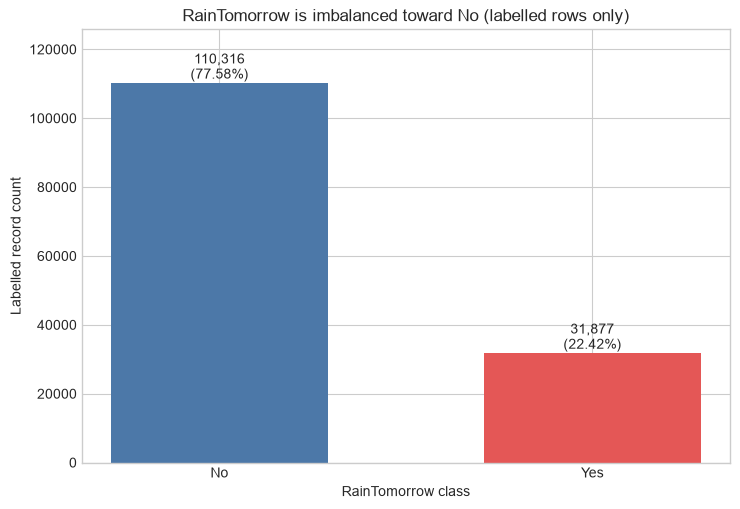

Observation: the descriptive majority-class accuracy is the No percentage; no classifier was trained.
Interpretation: overall accuracy alone could appear high while failing to identify many Yes cases.
Future consideration: later evaluation should include Yes-class precision, recall, F1, and PR-AUC.


In [3]:
target_table = target_distribution(weather)
target_table.to_csv(TABLE_DIR / "04_target_distribution.csv", index=False)
display(target_table)

target_counts = weather["RainTomorrow"].value_counts().reindex(["No", "Yes"])
target_percentages = target_counts / target_counts.sum() * 100
fig, ax = plt.subplots(figsize=(7.5, 5.2))
bars = ax.bar(target_counts.index, target_counts.values, color=[NO_COLOR, YES_COLOR], width=0.58)
for bar, count, percentage in zip(bars, target_counts, target_percentages):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{count:,}\n({percentage:.2f}%)", ha="center", va="bottom")
ax.set_title("RainTomorrow is imbalanced toward No (labelled rows only)")
ax.set_xlabel("RainTomorrow class")
ax.set_ylabel("Labelled record count")
ax.set_ylim(0, target_counts.max() * 1.14)
fig.tight_layout()
fig.savefig(TARGET_FIGURE_DIR / "04_target_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

print("Observation: the descriptive majority-class accuracy is the No percentage; no classifier was trained.")
print("Interpretation: overall accuracy alone could appear high while failing to identify many Yes cases.")
print("Future consideration: later evaluation should include Yes-class precision, recall, F1, and PR-AUC.")

## 2. Temporal target patterns

Month, year, and Southern Hemisphere season are temporary grouping variables for EDA only. Variation is descriptive and does not establish a causal seasonal effect.

,Month number,Month,Total record count,Labelled record count,Yes count,No count,Missing target count,Rain rate (Yes percentage)
0,1,January,13236,12921,2498,10423,315,19.3329
1,2,February,10793,10525,2207,8318,268,20.9691
2,3,March,13361,13036,2781,10255,325,21.3332
3,4,April,11550,11306,2463,8843,244,21.7849
4,5,May,13353,13055,2941,10114,298,22.5278
5,6,June,12684,12389,3244,9145,295,26.1845
6,7,July,12025,11779,3171,8608,246,26.9208
7,8,August,12028,11762,2970,8792,266,25.2508
8,9,September,11640,11345,2606,8739,295,22.9705
9,10,October,12028,11804,2310,9494,224,19.5696


,Year,Total record count,Labelled record count,Yes count,No count,Missing target count,Rain rate (Yes percentage)
0,2007,61,61,19,42,0,31.1475
1,2008,2270,2246,511,1735,24,22.7516
2,2009,16789,16595,3607,12988,194,21.7355
3,2010,16782,16419,3997,12422,363,24.3437
4,2011,15407,15126,3738,11388,281,24.7124
5,2012,15409,15044,3389,11655,365,22.5273
6,2013,16415,16097,3465,12632,318,21.5258
7,2014,17885,17400,3557,13843,485,20.4425
8,2015,17885,17231,3648,13583,654,21.1711
9,2016,17934,17508,4183,13325,426,23.8919


,Season,Total record count,Labelled record count,Yes count,No count,Missing target count,Rain rate (Yes percentage),EDA-only derivation note
0,Summer,35122,34256,6955,27301,866,20.3030,Southern Hemisphere season derived from Date for T04 description only; not an approved model feature.
1,Autumn,38264,37397,8185,29212,867,21.8868,Southern Hemisphere season derived from Date for T04 description only; not an approved model feature.
2,Winter,36737,35930,9385,26545,807,26.1202,Southern Hemisphere season derived from Date for T04 description only; not an approved model feature.
3,Spring,35337,34610,7352,27258,727,21.2424,Southern Hemisphere season derived from Date for T04 description only; not an approved model feature.


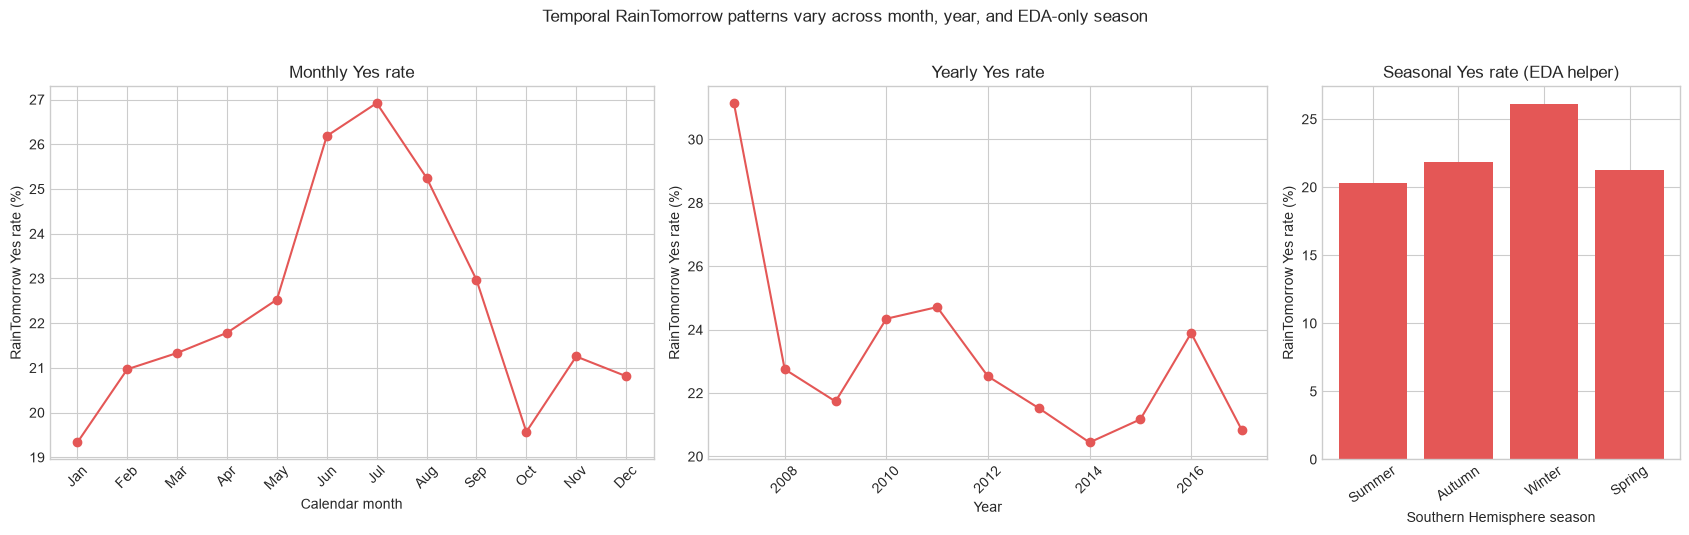

In [4]:
temporal = temporal_target_rates(weather)
temporal.by_month.to_csv(TABLE_DIR / "04_target_by_month.csv", index=False)
temporal.by_year.to_csv(TABLE_DIR / "04_target_by_year.csv", index=False)
temporal.by_season.to_csv(TABLE_DIR / "04_target_by_season.csv", index=False)
display(temporal.by_month)
display(temporal.by_year)
display(temporal.by_season)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), gridspec_kw={"width_ratios": [1.35, 1.25, 0.8]})
axes[0].plot(temporal.by_month["Month number"], temporal.by_month["Rain rate (Yes percentage)"], marker="o", color=YES_COLOR)
axes[0].set_xticks(range(1, 13), [name[:3] for name in temporal.by_month["Month"]], rotation=45)
axes[0].set_title("Monthly Yes rate")
axes[0].set_xlabel("Calendar month")
axes[0].set_ylabel("RainTomorrow Yes rate (%)")

axes[1].plot(temporal.by_year["Year"], temporal.by_year["Rain rate (Yes percentage)"], marker="o", color=YES_COLOR)
axes[1].set_title("Yearly Yes rate")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("RainTomorrow Yes rate (%)")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(temporal.by_season["Season"], temporal.by_season["Rain rate (Yes percentage)"], color=YES_COLOR)
axes[2].set_title("Seasonal Yes rate (EDA helper)")
axes[2].set_xlabel("Southern Hemisphere season")
axes[2].set_ylabel("RainTomorrow Yes rate (%)")
axes[2].tick_params(axis="x", rotation=35)
fig.suptitle("Temporal RainTomorrow patterns vary across month, year, and EDA-only season", y=1.02)
fig.tight_layout()
fig.savefig(TARGET_FIGURE_DIR / "04_temporal_target_patterns.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. Location versus target

,Location,Total record count,Labelled record count,Yes count,No count,Missing target count,Rain rate (Yes percentage),Observation-count flag,Rain-rate position
33,Portland,3009,2996,1095,1901,13,36.5487,Typical/higher count,Relatively high (upper quartile)
43,Walpole,3006,2819,949,1870,187,33.6644,Lower-quartile count; percentage may be less stable,Relatively high (upper quartile)
8,Cairns,3040,2988,950,2038,52,31.7938,Typical/higher count,Relatively high (upper quartile)
12,Dartmoor,3009,2943,922,2021,66,31.3286,Lower-quartile count; percentage may be less stable,Relatively high (upper quartile)
27,NorfolkIsland,3009,2964,919,2045,45,31.0054,Typical/higher count,Relatively high (upper quartile)
22,MountGambier,3040,3030,920,2110,10,30.3630,Typical/higher count,Relatively high (upper quartile)
1,Albany,3040,3016,902,2114,24,29.9072,Typical/higher count,Relatively high (upper quartile)
46,Witchcliffe,3009,2952,879,2073,57,29.7764,Typical/higher count,Relatively high (upper quartile)
11,CoffsHarbour,3009,2953,869,2084,56,29.4277,Typical/higher count,Relatively high (upper quartile)
23,MountGinini,3040,2907,819,2088,133,28.1734,Lower-quartile count; percentage may be less stable,Relatively high (upper quartile)


,Location,Total record count,Labelled record count,Yes count,No count,Missing target count,Rain rate (Yes percentage),Observation-count flag,Rain-rate position
41,Uluru,1578,1521,116,1405,57,7.6266,Lower-quartile count; percentage may be less stable,Relatively low (lower quartile)
16,Katherine,1578,1559,265,1294,19,16.9981,Lower-quartile count; percentage may be less stable,Relatively low (lower quartile)
25,Nhil,1578,1569,242,1327,9,15.4238,Lower-quartile count; percentage may be less stable,Relatively low (lower quartile)
18,Melbourne,3193,2435,636,1799,758,26.1191,Lower-quartile count; percentage may be less stable,Middle half
45,Williamtown,3009,2553,700,1853,456,27.4187,Lower-quartile count; percentage may be less stable,Relatively high (upper quartile)
29,PearceRAAF,3009,2762,505,2257,247,18.2839,Lower-quartile count; percentage may be less stable,Relatively low (lower quartile)
43,Walpole,3006,2819,949,1870,187,33.6644,Lower-quartile count; percentage may be less stable,Relatively high (upper quartile)
21,Moree,3009,2854,394,2460,155,13.8052,Lower-quartile count; percentage may be less stable,Relatively low (lower quartile)
23,MountGinini,3040,2907,819,2088,133,28.1734,Lower-quartile count; percentage may be less stable,Relatively high (upper quartile)
4,BadgerysCreek,3009,2928,583,2345,81,19.9112,Lower-quartile count; percentage may be less stable,Middle half


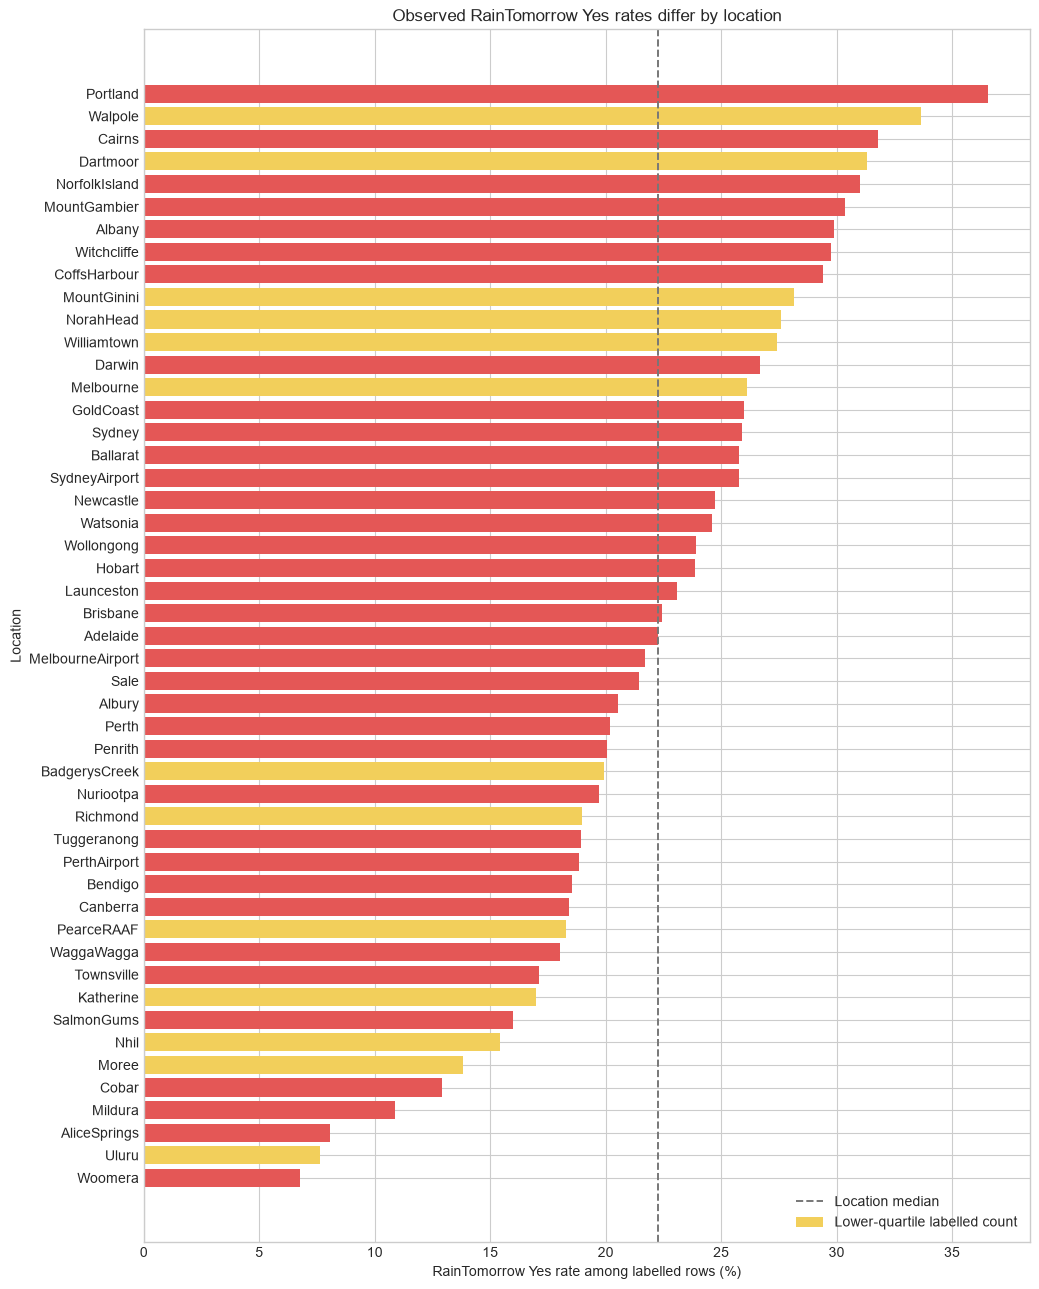

Observed location differences are not rankings of location quality and do not establish causation.


In [5]:
location_table = location_target_rates(weather)
location_table.to_csv(TABLE_DIR / "04_target_by_location.csv", index=False)
display(location_table.sort_values("Rain rate (Yes percentage)", ascending=False).head(12))
display(location_table.loc[location_table["Observation-count flag"].str.startswith("Lower")].sort_values("Labelled record count"))

plot_location = location_table.sort_values("Rain rate (Yes percentage)")
fig, ax = plt.subplots(figsize=(10.5, 13))
colors = np.where(plot_location["Observation-count flag"].str.startswith("Lower"), "#F2CF5B", YES_COLOR)
ax.barh(plot_location["Location"], plot_location["Rain rate (Yes percentage)"], color=colors)
median_line = ax.axvline(location_table["Rain rate (Yes percentage)"].median(), color=NEUTRAL_COLOR, linestyle="--", linewidth=1.4)
ax.set_title("Observed RainTomorrow Yes rates differ by location")
ax.set_xlabel("RainTomorrow Yes rate among labelled rows (%)")
ax.set_ylabel("Location")
ax.legend([median_line, Patch(facecolor="#F2CF5B")], ["Location median", "Lower-quartile labelled count"], loc="lower right")
fig.tight_layout()
fig.savefig(TARGET_FIGURE_DIR / "04_location_rain_rates.png", dpi=180, bbox_inches="tight")
plt.show()

print("Observed location differences are not rankings of location quality and do not establish causation.")

## 4. Numerical predictors versus target

Each summary uses labelled rows and the available, non-missing values for that predictor/class pair. Sample sizes and missing counts are retained. Extreme values are shown but are not classified or removed; that work belongs to T05.

,Feature,RainTomorrow,Labelled class count,Available count,Missing within class,Mean,Standard deviation,25th percentile,Median,75th percentile
0,MinTemp,No,110316,109854,462,11.8977,6.3987,7.3,11.8,16.5
1,MinTemp,Yes,31877,31702,175,13.1869,6.3180,8.5,12.7,17.9
2,MaxTemp,No,110316,110049,267,23.8362,7.0598,18.6,23.3,28.8
3,MaxTemp,Yes,31877,31822,55,21.1191,6.9115,16.1,20.2,25.8
4,Rainfall,No,110316,109586,730,1.2703,5.3322,0.0,0.0,0.2
5,Rainfall,Yes,31877,31201,676,6.1421,14.3183,0.0,0.8,6.2
6,Evaporation,No,110316,63491,46825,5.7348,4.3329,2.8,5.0,7.6
7,Evaporation,Yes,31877,17859,14018,4.5278,3.4691,2.2,3.8,6.2
8,Sunshine,No,110316,57556,52760,8.5464,3.3803,6.6,9.4,11.0
9,Sunshine,Yes,31877,16821,15056,4.4718,3.3593,1.4,4.3,7.1


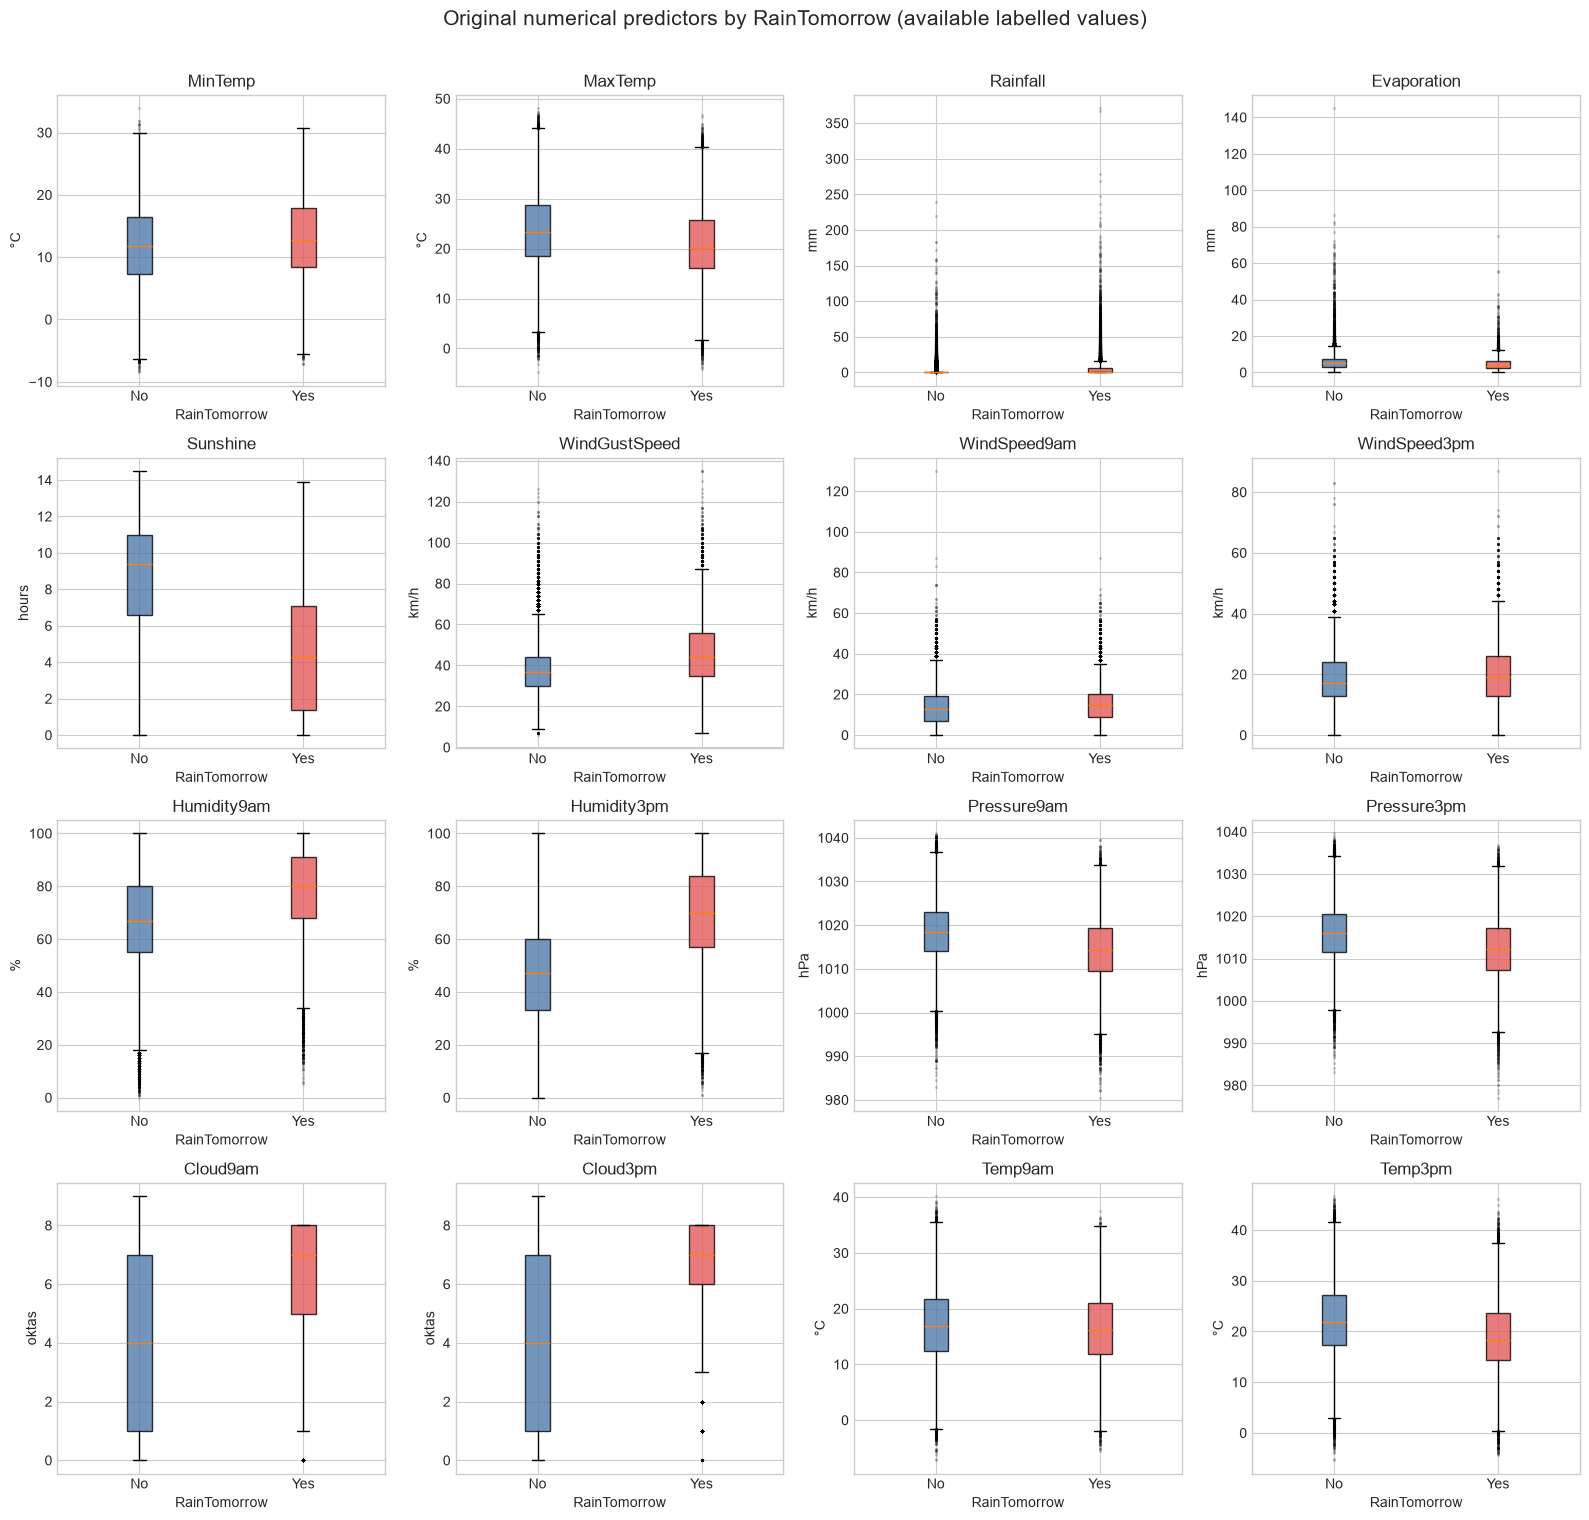

In [6]:
numeric_table = numeric_target_summary(weather)
numeric_table.to_csv(TABLE_DIR / "04_numeric_target_summary.csv", index=False)
display(numeric_table)

labelled = weather.loc[weather["RainTomorrow"].isin(["No", "Yes"])]
fig, axes = plt.subplots(4, 4, figsize=(16, 15))
unit_labels = {
    "MinTemp": "°C", "MaxTemp": "°C", "Temp9am": "°C", "Temp3pm": "°C",
    "Rainfall": "mm", "Evaporation": "mm", "Sunshine": "hours",
    "WindGustSpeed": "km/h", "WindSpeed9am": "km/h", "WindSpeed3pm": "km/h",
    "Humidity9am": "%", "Humidity3pm": "%", "Pressure9am": "hPa", "Pressure3pm": "hPa",
    "Cloud9am": "oktas", "Cloud3pm": "oktas",
}
for ax, feature in zip(axes.flat, NUMERIC_FEATURES):
    groups = [labelled.loc[labelled["RainTomorrow"] == value, feature].dropna().to_numpy() for value in ("No", "Yes")]
    box = ax.boxplot(groups, tick_labels=["No", "Yes"], patch_artist=True, showfliers=True,
                     flierprops={"markersize": 1.2, "alpha": 0.18})
    for patch, color in zip(box["boxes"], [NO_COLOR, YES_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.78)
    ax.set_title(feature)
    ax.set_xlabel("RainTomorrow")
    ax.set_ylabel(unit_labels[feature])
fig.suptitle("Original numerical predictors by RainTomorrow (available labelled values)", y=1.01, fontsize=15)
fig.tight_layout()
fig.savefig(RELATIONSHIP_FIGURE_DIR / "04_numeric_target_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Categorical predictors versus target

Compass directions remain original categories; no encoding is performed. `<Missing>` is retained as an EDA display category. Location appears in the location table/figure above and remains in the categorical summary below.

,Feature,Category,Category frequency among labelled rows,Category percentage among labelled rows,Yes count,No count,RainTomorrow Yes rate
0,RainToday,No,109332,76.8899,16604,92728,15.1868
1,RainToday,Yes,31455,22.1213,14597,16858,46.4060
2,RainToday,<Missing>,1406,0.9888,676,730,48.0797
3,WindGustDir,E,9071,6.3794,1350,7721,14.8826
4,WindGustDir,ENE,7992,5.6205,1288,6704,16.1161
...,...,...,...,...,...,...,...
98,Location,Watsonia,2999,2.1091,738,2261,24.6082
99,Location,Williamtown,2553,1.7954,700,1853,27.4187
100,Location,Witchcliffe,2952,2.0761,879,2073,29.7764
101,Location,Wollongong,2983,2.0979,713,2270,23.9021


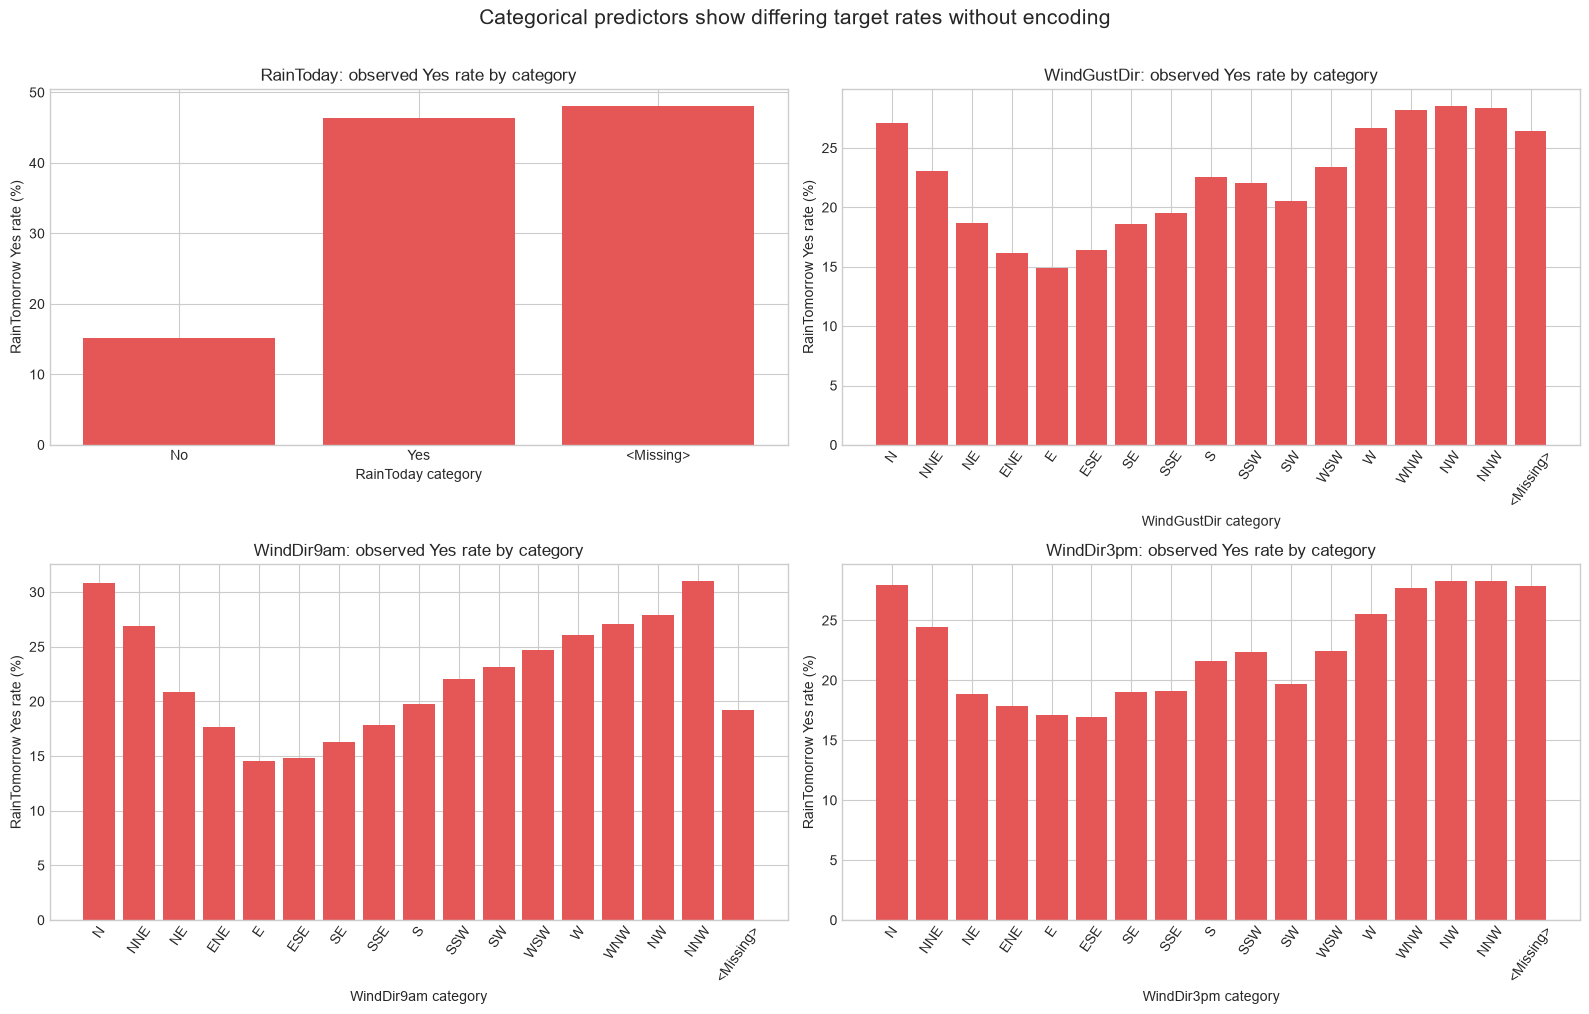

In [7]:
categorical_table = categorical_target_summary(weather)
categorical_table.to_csv(TABLE_DIR / "04_categorical_target_summary.csv", index=False)
display(categorical_table)

direction_order = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE", "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW", "<Missing>"]
plot_features = ["RainToday", "WindGustDir", "WindDir9am", "WindDir3pm"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, feature in zip(axes.flat, plot_features):
    data = categorical_table.loc[categorical_table["Feature"] == feature].copy()
    order = [value for value in (["No", "Yes", "<Missing>"] if feature == "RainToday" else direction_order) if value in set(data["Category"])]
    data = data.set_index("Category").reindex(order).reset_index()
    ax.bar(data["Category"], data["RainTomorrow Yes rate"], color=YES_COLOR)
    ax.set_title(f"{feature}: observed Yes rate by category")
    ax.set_xlabel(f"{feature} category")
    ax.set_ylabel("RainTomorrow Yes rate (%)")
    ax.tick_params(axis="x", rotation=55 if feature != "RainToday" else 0)
fig.suptitle("Categorical predictors show differing target rates without encoding", y=1.01, fontsize=15)
fig.tight_layout()
fig.savefig(RELATIONSHIP_FIGURE_DIR / "04_categorical_target_rates.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Correlation and possible redundancy

Pearson correlations use labelled rows and pairwise available predictor values. Correlation is descriptive evidence for later redundancy discussion; no feature is dropped here.

,Feature A,Feature B,Pearson correlation,Absolute correlation,Pairwise available count,Descriptive strength
0,MaxTemp,Temp3pm,0.984562,0.984562,139325,Very strong
1,Pressure9am,Pressure3pm,0.961348,0.961348,127989,Very strong
2,MinTemp,Temp9am,0.901813,0.901813,141008,Very strong
3,MaxTemp,Temp9am,0.887020,0.887020,141056,Strong
4,Temp9am,Temp3pm,0.860574,0.860574,138916,Strong
5,MinTemp,MaxTemp,0.736267,0.736267,141322,Strong
6,MinTemp,Temp3pm,0.708865,0.708865,139123,Strong
7,Sunshine,Cloud3pm,-0.704202,0.704202,64893,Strong
8,WindGustSpeed,WindSpeed3pm,0.686419,0.686419,132634,Moderate
9,Sunshine,Cloud9am,-0.675610,0.675610,66479,Moderate


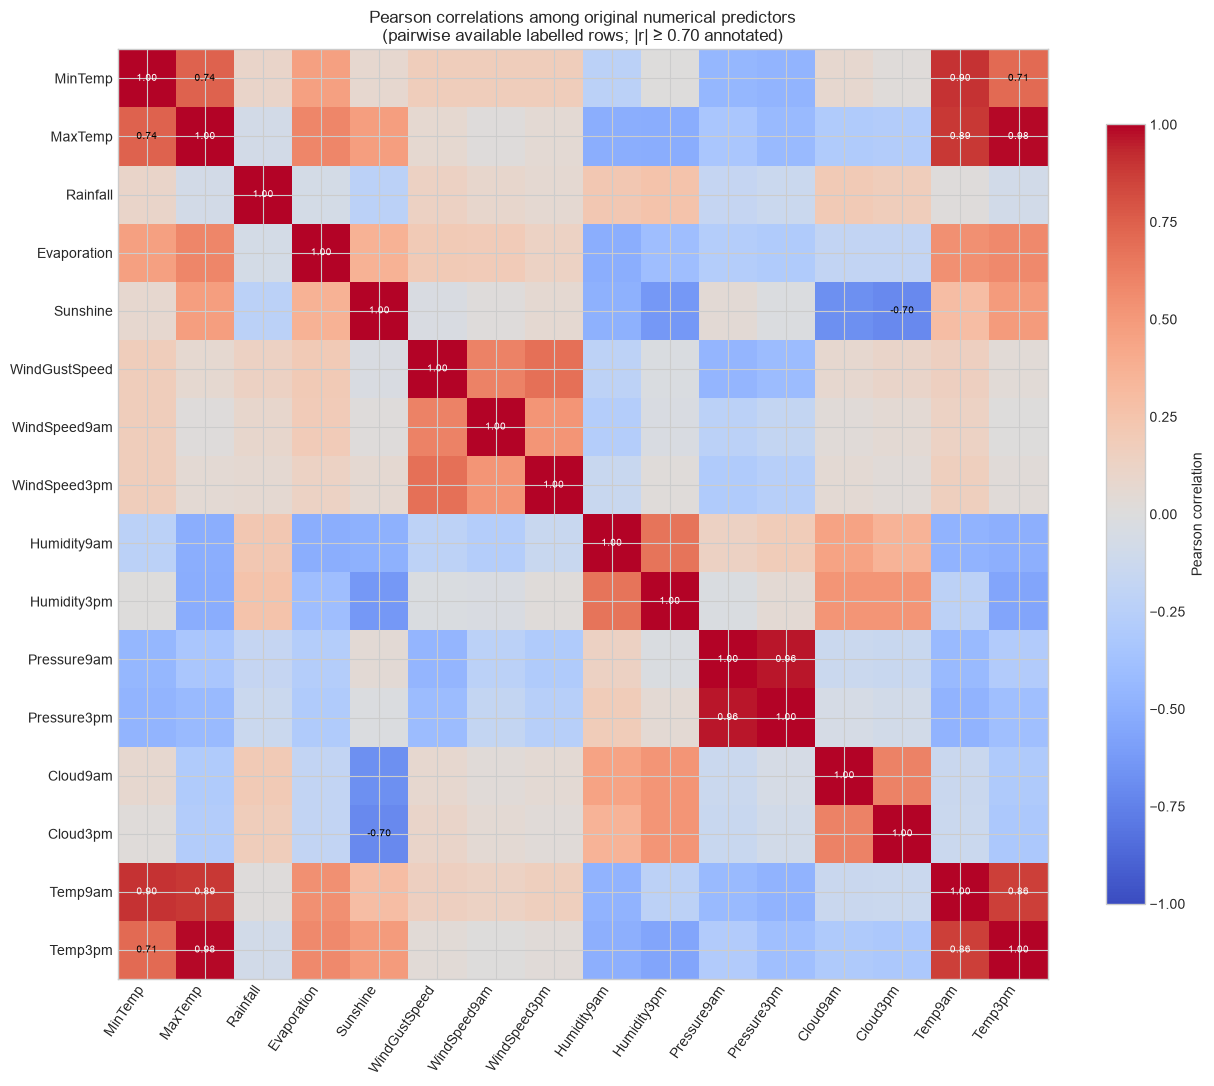

In [8]:
correlations = correlation_analysis(weather)
correlations.matrix.to_csv(TABLE_DIR / "04_correlation_matrix.csv", index=False)
correlations.pairs.to_csv(TABLE_DIR / "04_correlation_pairs.csv", index=False)
display(correlations.pairs.head(20))

corr_matrix = correlations.matrix.set_index("Feature")
fig, ax = plt.subplots(figsize=(13, 11))
image = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=55, ha="right")
ax.set_yticks(range(len(corr_matrix.index)), corr_matrix.index)
for row in range(len(corr_matrix.index)):
    for column in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[row, column]
        if abs(value) >= 0.7:
            ax.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(value) >= 0.82 else "black")
ax.set_title("Pearson correlations among original numerical predictors\n(pairwise available labelled rows; |r| ≥ 0.70 annotated)")
colorbar = fig.colorbar(image, ax=ax, shrink=0.8)
colorbar.set_label("Pearson correlation")
fig.tight_layout()
fig.savefig(RELATIONSHIP_FIGURE_DIR / "04_numeric_correlation_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. RainToday and Rainfall threshold/redundancy verification

The proposal wording is **"1 mm or more"** (Rainfall >= 1.0 mm). The checks below distinguish that wording from the dataset-observed convention, which is Rainfall > 1.0 mm for every usable Rainfall/RainToday pair.

In [9]:
rain_pair_table = raintoday_rainfall_relationship(weather)
rain_pair_table.to_csv(TABLE_DIR / "04_raintoday_rainfall_relationship.csv", index=False)
display(rain_pair_table)

print("Proposal wording: '1 mm or more' means Rainfall >= 1.0 mm and gives approximately 98.8% agreement.")
print("Dataset-observed convention: Rainfall > 1.0 mm matches RainToday for every usable pair.")
print("The 1,759 exact-boundary disagreements are a minor proposal-definition mismatch / boundary clarification.")
print("This verifies strong definitional redundancy but does not authorize dropping either original feature in T04.")

,Metric,Value,Context
0,Total dataset rows,145460,All records
1,Usable Rainfall/RainToday comparisons,142199,Both fields available
2,Target-labelled usable comparisons,140787,Both fields and RainTomorrow available
3,Rows with one or both fields missing,3261,"Excluded pairwise, not removed"
4,Both fields missing,3261,Missing-value effect
5,Rainfall-only missing,0,Missing-value effect
6,RainToday-only missing,0,Missing-value effect
7,Agreement count using Rainfall >= 1 mm,140440,Proposal threshold convention
8,Agreement percentage using Rainfall >= 1 mm,98.763,Percentage of usable pairs
9,Disagreement count using Rainfall >= 1 mm,1759,Usable pairs


Proposal wording: '1 mm or more' means Rainfall >= 1.0 mm and gives approximately 98.8% agreement.
Dataset-observed convention: Rainfall > 1.0 mm matches RainToday for every usable pair.
The 1,759 exact-boundary disagreements are a minor proposal-definition mismatch / boundary clarification.
This verifies strong definitional redundancy but does not authorize dropping either original feature in T04.


## 8. Target-association summary and important-domain interpretations

In [10]:
association_table = target_association_summary(weather, numeric_table, categorical_table)
interpretation_table = relationship_interpretations(association_table)
association_table.to_csv(TABLE_DIR / "04_target_association_summary.csv", index=False)
interpretation_table.to_csv(TABLE_DIR / "04_relationship_interpretations.csv", index=False)
display(association_table)
display(interpretation_table)

for row in interpretation_table.itertuples(index=False):
    print(f"\n{row.Feature}\nOBSERVATION: {row.Observation}\nINTERPRETATION: {row.Interpretation}\nFUTURE CONSIDERATION: {getattr(row, '_3')}")

,Feature,Feature type,Observed relationship with RainTomorrow,Descriptive association assessment,Missingness concern,Redundancy concern,Future consideration
0,MinTemp,Numerical,Median Yes=12.7 versus No=11.8; standardized mean difference=0.203.,Weak observed separation,Low (1.02%),"Correlated with Temp9am, Temp3pm, and MaxTemp",Retain for now; evaluate robustness and predictive contribution after leakage-safe splitting.
1,MaxTemp,Numerical,Median Yes=20.2 versus No=23.3; standardized mean difference=-0.389.,Weak observed separation,Low (0.87%),Very strongly correlated with Temp3pm; correlated with morning temperatures,Retain for now; evaluate robustness and predictive contribution after leakage-safe splitting.
2,Rainfall,Numerical,Median Yes=0.8 versus No=0; standardized mean difference=0.451.,Weak observed separation,Low (2.24%),Strong definitional overlap with RainToday threshold indicator,Retain for now; evaluate robustness and predictive contribution after leakage-safe splitting.
3,Evaporation,Numerical,Median Yes=3.8 versus No=5; standardized mean difference=-0.308.,Weak observed separation,High (43.17%),No specific high-correlation concern identified at T04,Retain for now; evaluate robustness and predictive contribution after leakage-safe splitting.
4,Sunshine,Numerical,Median Yes=4.3 versus No=9.4; standardized mean difference=-1.209.,Strong observed separation,High (48.01%),No specific high-correlation concern identified at T04,Retain for now; evaluate robustness and predictive contribution after leakage-safe splitting.
5,WindGustSpeed,Numerical,Median Yes=44 versus No=37; standardized mean difference=0.541.,Moderate observed association,Moderate (7.06%),No specific high-correlation concern identified at T04,Retain for now; evaluate robustness and predictive contribution after leakage-safe splitting.
6,WindSpeed9am,Numerical,Median Yes=15 versus No=13; standardized mean difference=0.213.,Weak observed separation,Low (1.21%),Related morning/afternoon wind-speed measure,Retain for now; evaluate robustness and predictive contribution after leakage-safe splitting.
7,WindSpeed3pm,Numerical,Median Yes=19 versus No=17; standardized mean difference=0.203.,Weak observed separation,Low (2.11%),Related morning/afternoon wind-speed measure,Retain for now; evaluate robustness and predictive contribution after leakage-safe splitting.
8,Humidity9am,Numerical,Median Yes=80 versus No=67; standardized mean difference=0.668.,Moderate observed association,Low (1.82%),Related morning/afternoon measure; correlation should be considered later,Retain for now; evaluate robustness and predictive contribution after leakage-safe splitting.
9,Humidity3pm,Numerical,Median Yes=70 versus No=47; standardized mean difference=1.188.,Strong observed separation,Low (3.10%),Related morning/afternoon measure; correlation should be considered later,Retain for now; evaluate robustness and predictive contribution after leakage-safe splitting.


,Feature,Observation,Interpretation,Future consideration
0,Humidity3pm,Median Yes=70 versus No=47; standardized mean difference=1.188.,"Higher afternoon humidity is consistent with wetter atmospheric conditions, but this is association, not causation.","Retain unchanged in T04; later evaluate non-linearity, redundancy, and predictive contribution using leakage-safe data."
1,Humidity9am,Median Yes=80 versus No=67; standardized mean difference=0.668.,"Morning humidity also differs by target class, with weaker separation than afternoon humidity.","Retain unchanged in T04; later evaluate non-linearity, redundancy, and predictive contribution using leakage-safe data."
2,Pressure3pm,Median Yes=1012.2 versus No=1016; standardized mean difference=-0.543.,Lower afternoon pressure is associated with next-day rain in this sample; weather systems and location may confound it.,"Retain unchanged in T04; later evaluate non-linearity, redundancy, and predictive contribution using leakage-safe data."
3,Pressure9am,Median Yes=1014.3 versus No=1018.5; standardized mean difference=-0.596.,"Lower morning pressure is associated with next-day rain, without establishing an independent causal effect.","Retain unchanged in T04; later evaluate non-linearity, redundancy, and predictive contribution using leakage-safe data."
4,Sunshine,Median Yes=4.3 versus No=9.4; standardized mean difference=-1.209.,Lower recorded sunshine accompanies more Yes labels where sunshine is observed; structural station missingness limit...,Later compare missingness-aware handling and coverage-sensitive usefulness; do not impute globally by default.
5,Cloud3pm,Median Yes=7 versus No=4; standardized mean difference=1.044.,"Greater afternoon cloud cover accompanies more Yes labels, subject to substantial station-dependent missingness.",Later assess missing indicators or station-aware handling and possible non-linear effects.
6,Cloud9am,Median Yes=7 versus No=4; standardized mean difference=0.844.,"Greater morning cloud cover accompanies more Yes labels, subject to substantial station-dependent missingness.",Later assess missing indicators or station-aware handling and possible non-linear effects.
7,Rainfall,Median Yes=0.8 versus No=0; standardized mean difference=0.451.,"Recent rainfall is associated with next-day rain, consistent with persistence in wet conditions; skew and threshold ...",Later assess transformation/non-linearity and redundancy with RainToday after the chronological split is fixed.
8,RainToday,Observed category Yes rates span 15.19% to 46.41% (range 31.22 percentage points).,"RainToday separates target rates and reflects recent rainfall status, but it substantially overlaps with Rainfall by...",Retain for now; later compare its incremental value against Rainfall without leakage.
9,WindGustSpeed,Median Yes=44 versus No=37; standardized mean difference=0.541.,"Higher gust speeds are associated with Yes labels, but the distributions overlap and extremes remain untreated.","Retain unchanged in T04; later evaluate non-linearity, redundancy, and predictive contribution using leakage-safe data."



Humidity3pm
OBSERVATION: Median Yes=70 versus No=47; standardized mean difference=1.188.
INTERPRETATION: Higher afternoon humidity is consistent with wetter atmospheric conditions, but this is association, not causation.
FUTURE CONSIDERATION: Retain unchanged in T04; later evaluate non-linearity, redundancy, and predictive contribution using leakage-safe data.

Humidity9am
OBSERVATION: Median Yes=80 versus No=67; standardized mean difference=0.668.
INTERPRETATION: Morning humidity also differs by target class, with weaker separation than afternoon humidity.
FUTURE CONSIDERATION: Retain unchanged in T04; later evaluate non-linearity, redundancy, and predictive contribution using leakage-safe data.

Pressure3pm
OBSERVATION: Median Yes=1012.2 versus No=1016; standardized mean difference=-0.543.
INTERPRETATION: Lower afternoon pressure is associated with next-day rain in this sample; weather systems and location may confound it.
FUTURE CONSIDERATION: Retain unchanged in T04; later evaluat

## 9. Limitations and deferred decisions

- Missing values were not imputed. Pairwise sample sizes are explicit in the numerical, categorical, and correlation outputs.
- Sunshine, Evaporation, Cloud9am, and Cloud3pm have substantial station-dependent missingness from T03, so their observed class separation reflects a restricted subset of stations/dates.
- These are unadjusted descriptive relationships. Location, season, station coverage, and correlated weather measurements may confound apparent associations; causation is not claimed.
- The class imbalance means overall accuracy alone could obscure poor Yes-class detection. Later model evaluation should inspect Yes precision, recall, F1, and PR-AUC.
- No class weighting, resampling, SMOTE, threshold optimization, outlier treatment, feature removal, encoding, or model training was performed.
- Potential transformations, interactions, missing indicators, redundancy decisions, and season as a possible feature remain future considerations only.

In [11]:
expected_tables = [
    "04_target_distribution.csv", "04_target_by_month.csv", "04_target_by_year.csv", "04_target_by_season.csv",
    "04_target_by_location.csv", "04_numeric_target_summary.csv", "04_categorical_target_summary.csv",
    "04_correlation_matrix.csv", "04_correlation_pairs.csv", "04_raintoday_rainfall_relationship.csv",
    "04_target_association_summary.csv", "04_relationship_interpretations.csv",
]
expected_figures = [
    TARGET_FIGURE_DIR / "04_target_distribution.png",
    TARGET_FIGURE_DIR / "04_temporal_target_patterns.png",
    TARGET_FIGURE_DIR / "04_location_rain_rates.png",
    RELATIONSHIP_FIGURE_DIR / "04_numeric_target_boxplots.png",
    RELATIONSHIP_FIGURE_DIR / "04_categorical_target_rates.png",
    RELATIONSHIP_FIGURE_DIR / "04_numeric_correlation_heatmap.png",
]
assert all((TABLE_DIR / name).is_file() for name in expected_tables)
assert all(path.is_file() for path in expected_figures)
assert int(target_table.loc[target_table["Metric"] == "Labelled total", "Value"].iloc[0]) == 142_193
assert len(numeric_table) == 32 and len(correlations.pairs) == 120
print(f"T04 notebook checks complete: {len(expected_tables)} tables and {len(expected_figures)} figures exist.")
print("No preprocessing, feature engineering, splitting, model training, or T05 work was performed.")

T04 notebook checks complete: 12 tables and 6 figures exist.
No preprocessing, feature engineering, splitting, model training, or T05 work was performed.
